# 07 - Synthetic benchmark v0.1: conditional fidelity validation

## tl;dr

Overall assessment from the executed run: **Needs revision**. The requested
conditional notebook was missing from the project; `06` is mostly a marginal
fidelity notebook. This notebook recomputes the requested conditional
comparisons from the real prepared BOAMP corpus and the current
`central_provisional` synthetic pilot.

The current pilot is close for `P(CPV missing | schema_family, notice_type)`,
but it does **not** reproduce several deeper structures:

- `P(SIRET present | schema_family, publication_year, notice_type)` has large
  post-2024 schema/type gaps.
- `P(duration present | schema_family, publication_year, notice_type)` has
  large EFORMS/LEGACY and notice-type gaps.
- `P(generic repeated text | notice_type, buyer_activity)` is much higher in
  the synthetic pilot than in the real corpus under a cross-buyer exact-template
  proxy.

The requested CPV-division conditioning is not fully identifiable in the real
data because `cpv_division` is derived from `cpv_clean`; when CPV is missing,
the division is missing too. The notebook records that identifiability check
instead of presenting a circular rate.


## Context & Methods

Reader-facing goal: determine whether the generator reproduces conditional
data-generating structure rather than only global totals.

Sources:

- Real corpus: `data/interim/boamp_common_prepared.csv`
- Synthetic pilot: `data/processed/synthetic_benchmark/v0_1_provisional/central_provisional/world_001/corruption_001/observed_notices.parquet`
- Existing production adapters: `boamp.synthetic.compatibility.adapt_observed_notices_to_sources`

### Key Assumptions

- SIRET presence is checksum-cleaned presence for both real and synthetic data.
- Duration presence uses raw declared duration availability, before imputation.
- CPV missingness uses `cpv_clean.isna()`.
- "Generic text" is proxied by an exact normalized text string reused by at
  least two distinct buyer keys. This intentionally targets cross-buyer
  boilerplate/template reuse, not within-family CALL/AWARD duplication.
- Comparisons with both real and synthetic `n >= 30` are used for headline
  summary statistics; sparse cells are still saved in the detailed tables.


## Data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from utils.text_clean import normalize_objet

setup_style()

SCENARIO = "central_provisional"
PILOT_DIR = PROJECT_ROOT / "data/processed/synthetic_benchmark/v0_1_provisional" / SCENARIO / "world_001/corruption_001"
REAL_PATH = PROJECT_ROOT / "data/interim/boamp_common_prepared.csv"

TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "synthetic_benchmark" / "v0_1"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "synthetic_benchmark" / "v0_1"
REPORT_DIR = PROJECT_ROOT / "reports" / "generated" / "synthetic_benchmark"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

REAL_USECOLS = [
    "notice_id", "schema_family", "notice_type_normalized", "publication_year",
    "buyer_siret_clean", "cpv_clean", "cpv_division", "duration_raw",
    "objet_normalized", "objet_clean", "buyer_key",
]

real = pd.read_csv(REAL_PATH, usecols=REAL_USECOLS, low_memory=False)
observed = pd.read_parquet(PILOT_DIR / "observed_notices.parquet")
synthetic = adapt_observed_notices_to_sources(observed)

synthetic["publication_year"] = pd.to_datetime(synthetic["publication_date"]).dt.year
synthetic["duration_raw"] = observed["declared_duration_months"]
synthetic["objet_normalized"] = synthetic["objet_clean"].map(normalize_objet)

print(f"real rows: {len(real):,}")
print(f"synthetic rows: {len(synthetic):,}")
print(f"synthetic pilot: {PILOT_DIR.relative_to(PROJECT_ROOT)}")

real rows: 84,623
synthetic rows: 9,537
synthetic pilot: data/processed/synthetic_benchmark/v0_1_provisional/central_provisional/world_001/corruption_001


### Prepare Common Flags

In [2]:
ACTIVITY_ORDER = ["1 (single)", "2-5", "6-20", "21+"]
NOTICE_ORDER = ["APPEL_OFFRE", "ATTRIBUTION", "OTHER"]
SCHEMA_ORDER = ["LEGACY", "EFORMS"]


def add_activity_tier(frame: pd.DataFrame, id_col: str) -> pd.DataFrame:
    out = frame.copy()
    counts = out.groupby("buyer_key", dropna=False)[id_col].transform("size")
    out["buyer_activity_tier"] = pd.cut(
        counts, bins=[0, 1, 5, 20, np.inf], labels=ACTIVITY_ORDER, right=True
    ).astype(str)
    return out


def add_generic_text_flag(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    text_stats = (
        out.dropna(subset=["objet_normalized"])
        .groupby("objet_normalized")
        .agg(n_notices=("objet_normalized", "size"), n_buyers=("buyer_key", "nunique"))
    )
    generic_texts = set(text_stats.query("n_notices >= 2 and n_buyers >= 2").index)
    out["generic_text"] = out["objet_normalized"].isin(generic_texts)
    return out


real = add_activity_tier(real, "notice_id")
synthetic = add_activity_tier(synthetic, "notice_id")
real = add_generic_text_flag(real)
synthetic = add_generic_text_flag(synthetic)

real["siret_present"] = real["buyer_siret_clean"].notna()
synthetic["siret_present"] = synthetic["buyer_siret_clean"].notna()
real["cpv_missing"] = real["cpv_clean"].isna()
synthetic["cpv_missing"] = synthetic["cpv_clean"].isna()
real["duration_present"] = real["duration_raw"].notna()
synthetic["duration_present"] = synthetic["duration_raw"].notna()

real["dataset"] = "real"
synthetic["dataset"] = "synthetic"

pd.DataFrame({
    "dataset": ["real", "synthetic"],
    "rows": [len(real), len(synthetic)],
    "years": [
        f"{int(real['publication_year'].min())}-{int(real['publication_year'].max())}",
        f"{int(synthetic['publication_year'].min())}-{int(synthetic['publication_year'].max())}",
    ],
    "siret_present": [real["siret_present"].mean(), synthetic["siret_present"].mean()],
    "cpv_missing": [real["cpv_missing"].mean(), synthetic["cpv_missing"].mean()],
    "duration_present": [real["duration_present"].mean(), synthetic["duration_present"].mean()],
    "generic_text": [real["generic_text"].mean(), synthetic["generic_text"].mean()],
})

,dataset,rows,years,siret_present,cpv_missing,duration_present,generic_text
0,real,84623,2015-2026,0.272243,0.170616,0.136452,0.078395
1,synthetic,9537,2015-2026,0.288665,0.151410,0.180770,0.537171


## Results

### Helpers: Rates, Wilson Confidence Intervals, and Exports

In [3]:
def wilson_interval(successes: pd.Series, n: pd.Series, z: float = 1.96) -> tuple[pd.Series, pd.Series]:
    successes = successes.astype(float)
    n = n.astype(float)
    phat = successes / n
    denom = 1 + z**2 / n
    centre = (phat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((phat * (1 - phat) / n) + (z**2 / (4 * n**2))) / denom
    return (centre - margin).clip(0, 1), (centre + margin).clip(0, 1)


def rate_table(frame: pd.DataFrame, outcome: str, group_cols: list[str], dataset: str) -> pd.DataFrame:
    grouped = (
        frame.groupby(group_cols, dropna=False)[outcome]
        .agg(successes="sum", n="count")
        .reset_index()
    )
    grouped["rate"] = grouped["successes"] / grouped["n"]
    grouped["ci_low"], grouped["ci_high"] = wilson_interval(grouped["successes"], grouped["n"])
    grouped["dataset"] = dataset
    return grouped


def compare_rates(outcome: str, group_cols: list[str], table_name: str) -> pd.DataFrame:
    real_rates = rate_table(real, outcome, group_cols, "real")
    synthetic_rates = rate_table(synthetic, outcome, group_cols, "synthetic")
    merged = real_rates.merge(synthetic_rates, on=group_cols, how="outer", suffixes=("_real", "_synthetic"))
    merged["diff_pp"] = (merged["rate_synthetic"] - merged["rate_real"]) * 100
    merged["abs_diff_pp"] = merged["diff_pp"].abs()
    merged["ci_overlap"] = (
        merged["ci_low_real"].le(merged["ci_high_synthetic"])
        & merged["ci_low_synthetic"].le(merged["ci_high_real"])
    )
    ordered_cols = (
        group_cols
        + [
            "n_real", "successes_real", "rate_real", "ci_low_real", "ci_high_real",
            "n_synthetic", "successes_synthetic", "rate_synthetic", "ci_low_synthetic", "ci_high_synthetic",
            "diff_pp", "abs_diff_pp", "ci_overlap",
        ]
    )
    out = merged[ordered_cols].sort_values(["abs_diff_pp"] + group_cols, ascending=[False] + [True] * len(group_cols))
    out.to_csv(TABLES_DIR / table_name, index=False)
    return out


def headline_stats(comp: pd.DataFrame, comparison: str, min_n: int = 30) -> dict:
    eligible = comp[(comp["n_real"].fillna(0) >= min_n) & (comp["n_synthetic"].fillna(0) >= min_n)]
    return {
        "comparison": comparison,
        "cells_total": len(comp),
        "cells_with_n_ge_30_both": len(eligible),
        "mean_abs_diff_pp": eligible["abs_diff_pp"].mean(),
        "median_abs_diff_pp": eligible["abs_diff_pp"].median(),
        "p90_abs_diff_pp": eligible["abs_diff_pp"].quantile(0.9),
        "max_abs_diff_pp": eligible["abs_diff_pp"].max(),
        "share_ci_overlap": eligible["ci_overlap"].mean(),
    }


def heatmap_ppdiff(comp: pd.DataFrame, row: str, col: str, title: str, filename: str, facet_filter: dict | None = None):
    plot_df = comp.copy()
    subtitle = ""
    if facet_filter:
        for key, value in facet_filter.items():
            plot_df = plot_df[plot_df[key].eq(value)]
        subtitle = " | " + ", ".join(f"{k}={v}" for k, v in facet_filter.items())
    pivot = plot_df.pivot_table(index=row, columns=col, values="diff_pp", aggfunc="mean")
    fig_width = max(5, 0.55 * len(pivot.columns) + 2.5)
    fig_height = max(3.5, 0.36 * len(pivot.index) + 1.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    vmax = float(np.nanmax(np.abs(pivot.values))) if pivot.size else 1
    vmax = max(vmax, 1)
    im = ax.imshow(pivot.values, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax), aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=40, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title + subtitle)
    ax.set_xlabel(col)
    ax.set_ylabel(row)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Synthetic - real (percentage points)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{filename}.png", bbox_inches="tight", dpi=150)
    fig.savefig(FIG_DIR / f"{filename}.pdf", bbox_inches="tight")
    return fig

### 1. `P(SIRET present | schema_family, publication_year, notice_type)`

In [4]:
siret_comparison = compare_rates(
    "siret_present",
    ["schema_family", "publication_year", "notice_type_normalized"],
    "conditional_fidelity_siret_by_schema_year_notice_type.csv",
)
siret_summary = headline_stats(siret_comparison, "P(SIRET present | schema, year, notice type)")
siret_summary, siret_comparison.head(12)

({'comparison': 'P(SIRET present | schema, year, notice type)',
  'cells_total': 45,
  'cells_with_n_ge_30_both': 29,
  'mean_abs_diff_pp': np.float64(19.886203616431956),
  'median_abs_diff_pp': np.float64(11.17497333729151),
  'p90_abs_diff_pp': np.float64(44.78513650705943),
  'max_abs_diff_pp': np.float64(58.44155844155844),
  'share_ci_overlap': np.float64(0.3103448275862069)},
    schema_family  publication_year notice_type_normalized  n_real  \
 43        LEGACY              2026            ATTRIBUTION     197   
 42        LEGACY              2026            APPEL_OFFRE    1130   
 40        LEGACY              2025            ATTRIBUTION     429   
 36        LEGACY              2024            APPEL_OFFRE    2667   
 0         EFORMS              2024            APPEL_OFFRE    2638   
 1         EFORMS              2024            ATTRIBUTION    1399   
 39        LEGACY              2025            APPEL_OFFRE    2666   
 37        LEGACY              2024            ATTRIBU

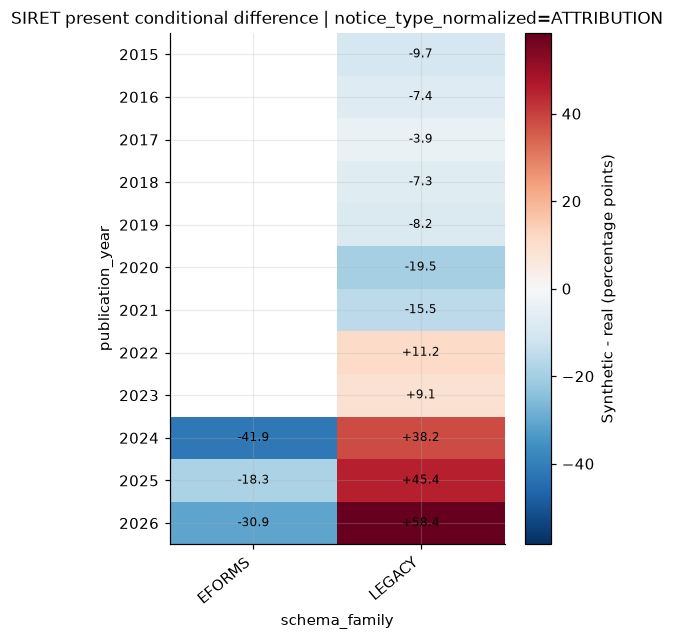

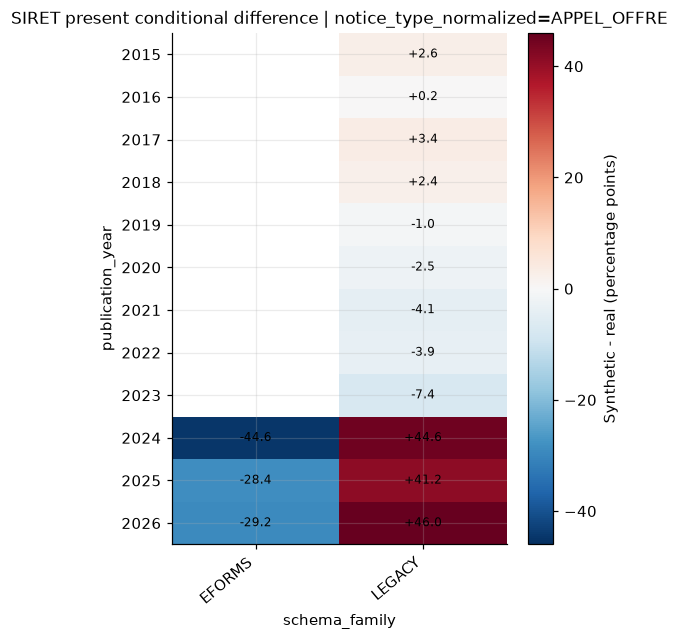

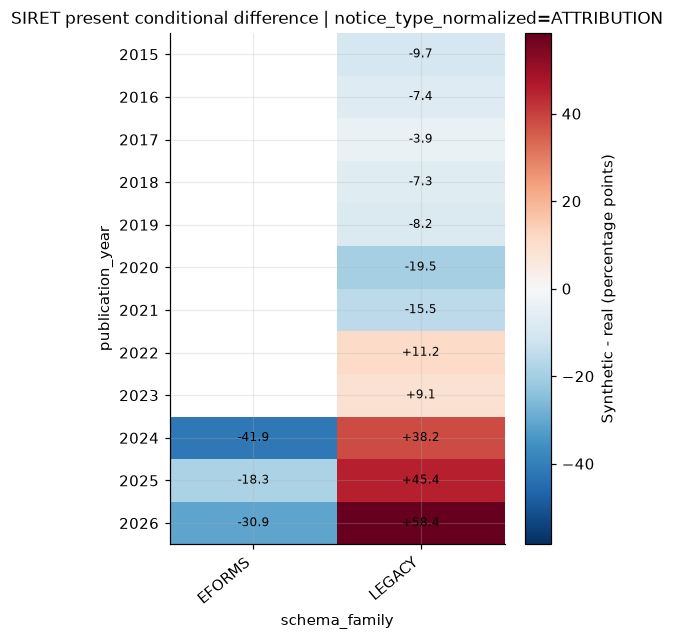

In [5]:
heatmap_ppdiff(
    siret_comparison,
    row="publication_year",
    col="schema_family",
    title="SIRET present conditional difference",
    filename="conditional_fidelity_siret_ppdiff_appel_offre",
    facet_filter={"notice_type_normalized": "APPEL_OFFRE"},
)
heatmap_ppdiff(
    siret_comparison,
    row="publication_year",
    col="schema_family",
    title="SIRET present conditional difference",
    filename="conditional_fidelity_siret_ppdiff_attribution",
    facet_filter={"notice_type_normalized": "ATTRIBUTION"},
)

### 2. `P(CPV missing | schema_family, notice_type)` and CPV-Division Identifiability

In [6]:
cpv_comparison = compare_rates(
    "cpv_missing",
    ["schema_family", "notice_type_normalized"],
    "conditional_fidelity_cpv_missing_by_schema_notice_type.csv",
)
cpv_summary = headline_stats(cpv_comparison, "P(CPV missing | schema, notice type)")
cpv_summary, cpv_comparison

({'comparison': 'P(CPV missing | schema, notice type)',
  'cells_total': 6,
  'cells_with_n_ge_30_both': 4,
  'mean_abs_diff_pp': np.float64(1.6533371376196109),
  'median_abs_diff_pp': np.float64(1.356995922181654),
  'p90_abs_diff_pp': np.float64(2.571195430436557),
  'max_abs_diff_pp': np.float64(3.038215694274446),
  'share_ci_overlap': np.float64(0.25)},
   schema_family notice_type_normalized  n_real  successes_real  rate_real  \
 3        LEGACY            APPEL_OFFRE   51471           12460   0.242078   
 1        EFORMS            ATTRIBUTION    3787               0   0.000000   
 4        LEGACY            ATTRIBUTION   18773            1611   0.085815   
 0        EFORMS            APPEL_OFFRE    6821               0   0.000000   
 2        EFORMS                  OTHER      74               0   0.000000   
 5        LEGACY                  OTHER    3697             367   0.099270   
 
    ci_low_real  ci_high_real  n_synthetic  successes_synthetic  \
 3     0.238397      0.

In [7]:
def cpv_division_identifiability(frame: pd.DataFrame, dataset: str) -> pd.DataFrame:
    diag = frame.copy()
    diag["cpv_division_state"] = np.where(diag["cpv_division"].notna(), "OBSERVED_DIVISION", "NO_OBSERVED_CPV_DIVISION")
    out = rate_table(diag, "cpv_missing", ["cpv_division_state"], dataset)
    return out[["dataset", "cpv_division_state", "n", "successes", "rate", "ci_low", "ci_high"]]


cpv_division_diag = pd.concat(
    [cpv_division_identifiability(real, "real"), cpv_division_identifiability(synthetic, "synthetic")],
    ignore_index=True,
)
cpv_division_diag.to_csv(TABLES_DIR / "conditional_fidelity_cpv_division_identifiability.csv", index=False)
cpv_division_diag

,dataset,cpv_division_state,n,successes,rate,ci_low,ci_high
0,real,NO_OBSERVED_CPV_DIVISION,14438,14438,1.0,0.999734,1.000000
1,real,OBSERVED_DIVISION,70185,0,0.0,0.000000,0.000055
2,synthetic,NO_OBSERVED_CPV_DIVISION,1444,1444,1.0,0.997347,1.000000
3,synthetic,OBSERVED_DIVISION,8093,0,0.0,0.000000,0.000474


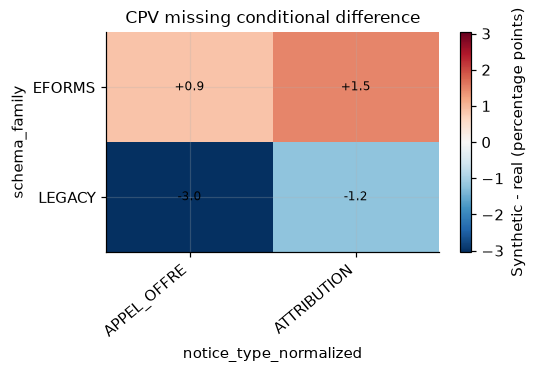

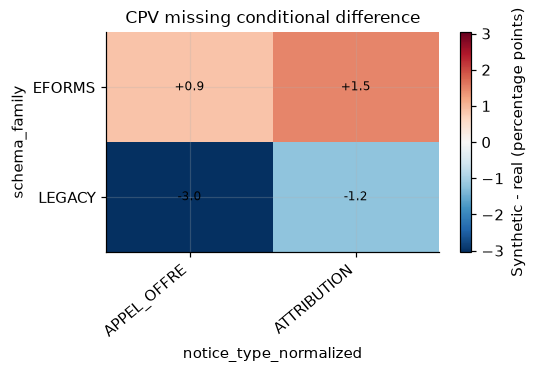

In [8]:
heatmap_ppdiff(
    cpv_comparison,
    row="schema_family",
    col="notice_type_normalized",
    title="CPV missing conditional difference",
    filename="conditional_fidelity_cpv_missing_ppdiff",
)

### 3. `P(duration present | schema_family, notice_type, publication_year)`

In [9]:
duration_comparison = compare_rates(
    "duration_present",
    ["schema_family", "publication_year", "notice_type_normalized"],
    "conditional_fidelity_duration_by_schema_year_notice_type.csv",
)
duration_summary = headline_stats(duration_comparison, "P(duration present | schema, notice type, year)")
duration_summary, duration_comparison.head(12)

({'comparison': 'P(duration present | schema, notice type, year)',
  'cells_total': 45,
  'cells_with_n_ge_30_both': 29,
  'mean_abs_diff_pp': np.float64(14.96585939860095),
  'median_abs_diff_pp': np.float64(6.0152810152810146),
  'p90_abs_diff_pp': np.float64(51.592637961752004),
  'max_abs_diff_pp': np.float64(68.00232437352477),
  'share_ci_overlap': np.float64(0.10344827586206896)},
    schema_family  publication_year notice_type_normalized  n_real  \
 1         EFORMS              2024            ATTRIBUTION    1399   
 42        LEGACY              2026            APPEL_OFFRE    1130   
 39        LEGACY              2025            APPEL_OFFRE    2666   
 36        LEGACY              2024            APPEL_OFFRE    2667   
 4         EFORMS              2025            ATTRIBUTION    1539   
 7         EFORMS              2026            ATTRIBUTION     849   
 0         EFORMS              2024            APPEL_OFFRE    2638   
 31        LEGACY              2022            AT

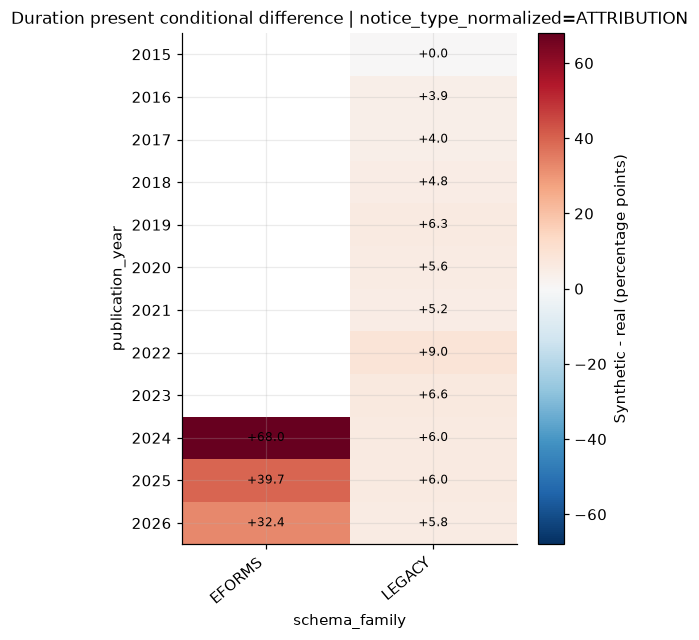

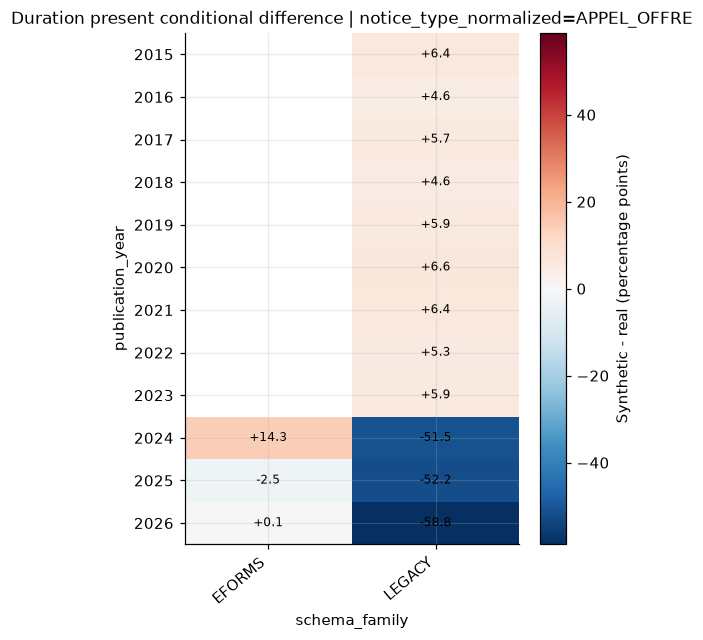

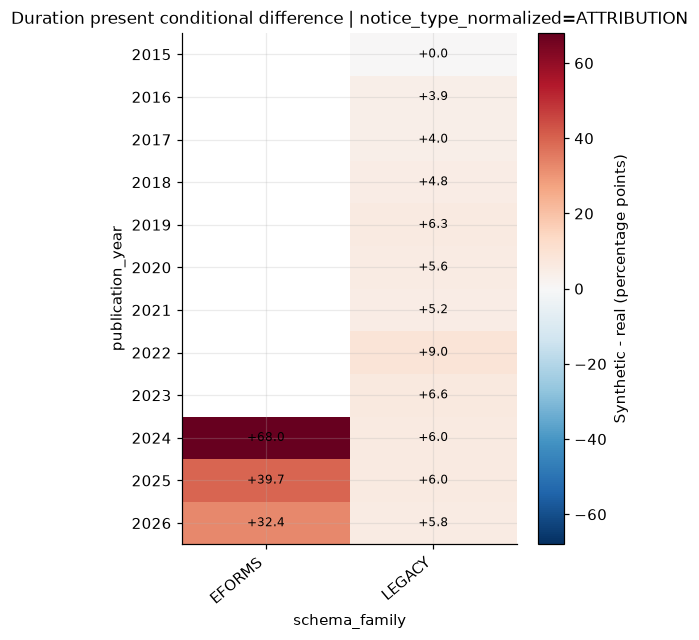

In [10]:
heatmap_ppdiff(
    duration_comparison,
    row="publication_year",
    col="schema_family",
    title="Duration present conditional difference",
    filename="conditional_fidelity_duration_ppdiff_appel_offre",
    facet_filter={"notice_type_normalized": "APPEL_OFFRE"},
)
heatmap_ppdiff(
    duration_comparison,
    row="publication_year",
    col="schema_family",
    title="Duration present conditional difference",
    filename="conditional_fidelity_duration_ppdiff_attribution",
    facet_filter={"notice_type_normalized": "ATTRIBUTION"},
)

### 4. `P(generic repeated text | notice_type, buyer_activity)`

In [11]:
generic_text_comparison = compare_rates(
    "generic_text",
    ["notice_type_normalized", "buyer_activity_tier"],
    "conditional_fidelity_generic_text_by_notice_type_buyer_activity.csv",
)
generic_text_summary = headline_stats(
    generic_text_comparison,
    "P(generic repeated text | notice type, buyer activity)",
)
generic_text_summary, generic_text_comparison.head(12)

({'comparison': 'P(generic repeated text | notice type, buyer activity)',
  'cells_total': 12,
  'cells_with_n_ge_30_both': 8,
  'mean_abs_diff_pp': np.float64(46.27627192575842),
  'median_abs_diff_pp': np.float64(42.78535234585273),
  'p90_abs_diff_pp': np.float64(63.71401788407192),
  'max_abs_diff_pp': np.float64(67.10792828193665),
  'share_ci_overlap': np.float64(0.0)},
    notice_type_normalized buyer_activity_tier  n_real  successes_real  \
 6             ATTRIBUTION                 21+   19376            2008   
 2             APPEL_OFFRE                 21+   45763            2958   
 7             ATTRIBUTION                6-20    1994             243   
 5             ATTRIBUTION                 2-5     947             106   
 0             APPEL_OFFRE          1 (single)    1709             135   
 3             APPEL_OFFRE                6-20    6926             520   
 1             APPEL_OFFRE                 2-5    3894             306   
 4             ATTRIBUTION   

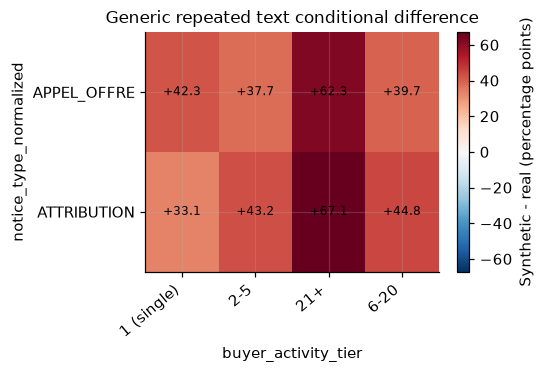

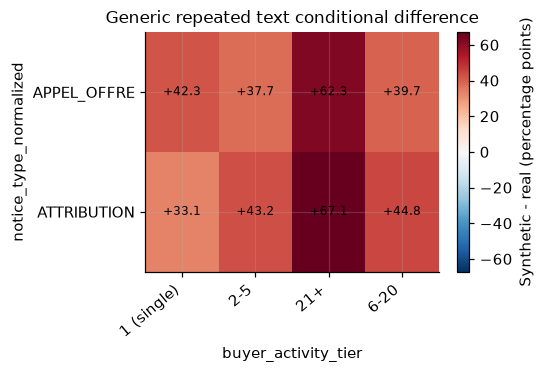

In [12]:
heatmap_ppdiff(
    generic_text_comparison,
    row="notice_type_normalized",
    col="buyer_activity_tier",
    title="Generic repeated text conditional difference",
    filename="conditional_fidelity_generic_text_ppdiff",
)

### Summary Table

In [13]:
summary = pd.DataFrame([siret_summary, cpv_summary, duration_summary, generic_text_summary])
summary["assessment"] = np.where(
    summary["max_abs_diff_pp"].le(5), "PASS",
    np.where(summary["median_abs_diff_pp"].le(5), "PASS_WITH_LIMITATION", "NEEDS_REVISION")
)
summary.to_csv(TABLES_DIR / "conditional_fidelity_summary.csv", index=False)
summary

,comparison,cells_total,cells_with_n_ge_30_both,mean_abs_diff_pp,median_abs_diff_pp,p90_abs_diff_pp,max_abs_diff_pp,share_ci_overlap,assessment
0,"P(SIRET present | schema, year, notice type)",45,29,19.886204,11.174973,44.785137,58.441558,0.310345,NEEDS_REVISION
1,"P(CPV missing | schema, notice type)",6,4,1.653337,1.356996,2.571195,3.038216,0.250000,PASS
2,"P(duration present | schema, notice type, year)",45,29,14.965859,6.015281,51.592638,68.002324,0.103448,NEEDS_REVISION
3,"P(generic repeated text | notice type, buyer a...",12,8,46.276272,42.785352,63.714018,67.107928,0.000000,NEEDS_REVISION


## Takeaways

In [14]:
def simple_markdown_table(frame: pd.DataFrame) -> str:
    display = frame.copy()
    for col in display.columns:
        if pd.api.types.is_float_dtype(display[col]):
            display[col] = display[col].map(lambda v: "" if pd.isna(v) else f"{v:.2f}")
    cols = list(display.columns)
    lines = [
        "| " + " | ".join(cols) + " |",
        "| " + " | ".join(["---"] * len(cols)) + " |",
    ]
    for _, row in display.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in cols) + " |")
    return "\n".join(lines)


report_lines = [
    "# Synthetic benchmark v0.1 - conditional fidelity validation",
    "",
    "Generated from `notebooks/07_synthetic_conditional_fidelity_validation.ipynb`.",
    "",
    "## Overall assessment",
    "",
    "**Needs revision.** CPV missingness by schema and notice type is close, but the current synthetic pilot does not reproduce the requested SIRET, duration, or generic-text conditional structures.",
    "",
    "## Headline metrics",
    "",
    simple_markdown_table(summary),
    "",
    "## Output tables",
    "",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_siret_by_schema_year_notice_type.csv`",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_cpv_missing_by_schema_notice_type.csv`",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_cpv_division_identifiability.csv`",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_duration_by_schema_year_notice_type.csv`",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_generic_text_by_notice_type_buyer_activity.csv`",
    "- `reports/tables/synthetic_benchmark/v0_1/conditional_fidelity_summary.csv`",
    "",
    "## Caveat",
    "",
    "`P(CPV missing | CPV division)` is not identifiable from the prepared real corpus because `cpv_division` is derived from `cpv_clean`; if CPV is missing, the division is also missing. The notebook saves an identifiability diagnostic rather than a circular division-conditioned missingness rate.",
]
(REPORT_DIR / "v0_1_conditional_fidelity_report.md").write_text("\n".join(report_lines) + "\n")
print("\n".join(report_lines[:16]))

# Synthetic benchmark v0.1 - conditional fidelity validation

Generated from `notebooks/07_synthetic_conditional_fidelity_validation.ipynb`.

## Overall assessment

**Needs revision.** CPV missingness by schema and notice type is close, but the current synthetic pilot does not reproduce the requested SIRET, duration, or generic-text conditional structures.

## Headline metrics

| comparison | cells_total | cells_with_n_ge_30_both | mean_abs_diff_pp | median_abs_diff_pp | p90_abs_diff_pp | max_abs_diff_pp | share_ci_overlap | assessment |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| P(SIRET present | schema, year, notice type) | 45 | 29 | 19.89 | 11.17 | 44.79 | 58.44 | 0.31 | NEEDS_REVISION |
| P(CPV missing | schema, notice type) | 6 | 4 | 1.65 | 1.36 | 2.57 | 3.04 | 0.25 | PASS |
| P(duration present | schema, notice type, year) | 45 | 29 | 14.97 | 6.02 | 51.59 | 68.00 | 0.10 | NEEDS_REVISION |
| P(generic repeated text | notice type, buyer activity) | 12 | 8 | 46.28 | 4